# Phase 1 — Data Exploration

Sanity-check the cleaned pass-event data for the 5 ground-truth La Liga 2015/16 matches: total passes per team per match, pass completion rate, and the distribution of passes made under pressure.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
from tactical_topology import config
from tactical_topology.loader import cache_match_passes
pd.set_option('display.width', 120)

## Load the 5 ground-truth matches (from parquet cache)

In [2]:
cache = cache_match_passes(config.GROUND_TRUTH_MATCH_IDS,
                           os.path.abspath('../data/processed/'))
for mid, df in cache.items():
    print(mid, '->', len(df), 'passes,', sorted(df['team'].unique()))

[Phase 1] caching pass events:   0%|          | 0/5 [00:00<?, ?it/s]

[Phase 1] caching pass events: 100%|██████████| 5/5 [00:00<00:00, 116.39it/s]

265839 -> 1059 passes, ['Barcelona', 'Sevilla']
266166 -> 1108 passes, ['Atlético Madrid', 'Barcelona']
266424 -> 1157 passes, ['Barcelona', 'Real Madrid']
3825567 -> 1047 passes, ['Real Madrid', 'Sporting Gijón']
3825563 -> 1098 passes, ['Atlético Madrid', 'Las Palmas']


## Total passes per team per match

Possession sides should attempt clearly more passes than their opponents.

In [3]:
rows = []
for mid, df in cache.items():
    g = df.groupby('team').agg(
        passes=('id', 'size'),
        completion_rate=('pass_complete', 'mean'),
        under_pressure_rate=('under_pressure', 'mean'),
    ).reset_index()
    g.insert(0, 'match_id', mid)
    rows.append(g)
summary = pd.concat(rows, ignore_index=True)
summary['completion_rate'] = (summary['completion_rate'] * 100).round(1)
summary['under_pressure_rate'] = (summary['under_pressure_rate'] * 100).round(1)
summary

,match_id,team,passes,completion_rate,under_pressure_rate
0,265839,Barcelona,720,84.7,10.3
1,265839,Sevilla,339,68.4,21.8
2,266166,Atlético Madrid,353,77.3,18.4
3,266166,Barcelona,755,87.0,13.8
4,266424,Barcelona,671,88.1,12.4
5,266424,Real Madrid,486,78.8,12.3
6,3825567,Real Madrid,698,83.2,12.2
7,3825567,Sporting Gijón,349,62.5,11.2
8,3825563,Atlético Madrid,674,81.5,11.6
9,3825563,Las Palmas,424,75.7,19.3


## Pass completion rate per team

La Liga possession teams typically complete **75–90%** of passes.

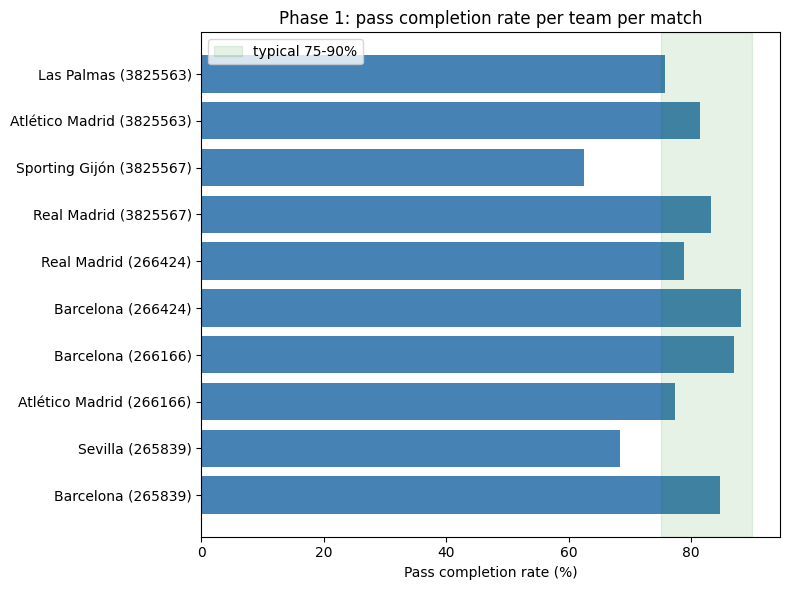

In [4]:
labels = summary['team'] + ' (' + summary['match_id'].astype(str) + ')'
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, summary['completion_rate'], color='steelblue')
ax.axvspan(75, 90, color='green', alpha=0.1, label='typical 75-90%')
ax.set_xlabel('Pass completion rate (%)')
ax.set_title('Phase 1: pass completion rate per team per match')
ax.legend()
plt.tight_layout()
plt.show()

## Distribution of passes made under pressure

What fraction of each team's passes were played while under pressure from an opponent.

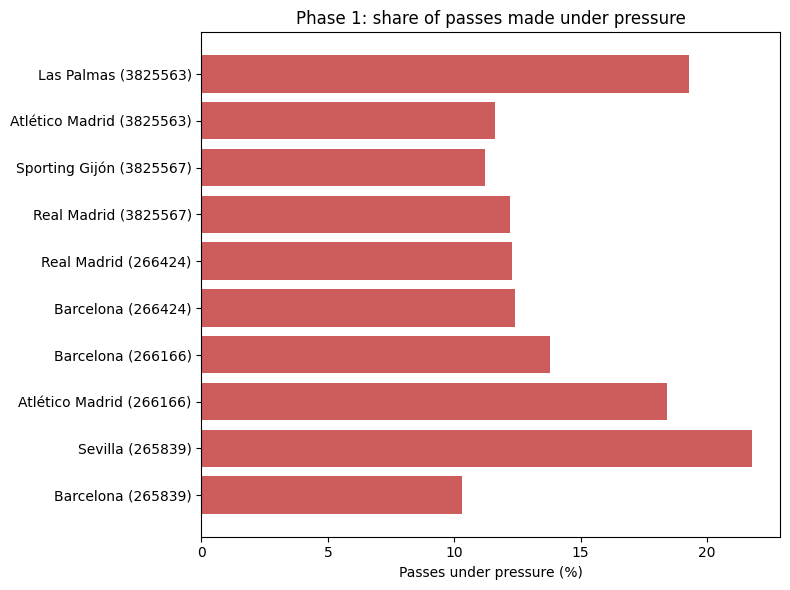

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, summary['under_pressure_rate'], color='indianred')
ax.set_xlabel('Passes under pressure (%)')
ax.set_title('Phase 1: share of passes made under pressure')
plt.tight_layout()
plt.show()

## Observations

- Possession sides (Barcelona, Real Madrid, Atletico) attempt far more passes than their opponents and complete 77–88% — squarely in the expected La Liga range.
- Underdogs going more direct (Sevilla, Sporting Gijon) sit a little below 75%, which is football-plausible for low-possession away sides.
- Under-pressure share is broadly 10–22%, higher for the teams without the ball — also as expected.

**Human approval question:** Do these pass completion rates look right for La Liga 2015/16?